# Figure 3 Replication: No-Prompt ↔ Chain-of-Thought Cross-Condition Generalization

**Paper Context**: *Testing the Limits of Truth Directions in LLMs* (Poulis et al., 2024 / 2026)

## Experimental Objective
In Poulis et al., **Figure 3** evaluates whether truth directions learned under one prompt condition generalize to internal representations produced under another prompt condition. In the original paper, probes were trained on unprompted plaintext activations and evaluated on `ask-correct` activations.

In this project, we substitute our canonical **sentence-based Chain-of-Thought (CoT)** condition everywhere Poulis uses `ask-correct`. Furthermore, while Poulis only evaluated one transfer direction, **we evaluate both transfer directions symmetrically across all 33 layers (0 through 32)**:

1. **Direction A (CoT → No-Prompt)**:
   - Train linear probe on `sentence-based-CoT` train activations: $\mathbf{w}_{\text{CoT}}, \boldsymbol{\mu}_{\text{CoT}}$
   - Score on `no-prompt-chat-template` test activations: $\text{logits} = (\mathbf{X}_{\text{NP, test}} - \boldsymbol{\mu}_{\text{CoT}}) \mathbf{w}_{\text{CoT}}$
   - Record AUROC against ground-truth labels.

2. **Direction B (No-Prompt → CoT)**:
   - Train linear probe on `no-prompt-chat-template` train activations: $\mathbf{w}_{\text{NP}}, \boldsymbol{\mu}_{\text{NP}}$
   - Score on `sentence-based-CoT` test activations: $\text{logits} = (\mathbf{X}_{\text{CoT, test}} - \boldsymbol{\mu}_{\text{NP}}) \mathbf{w}_{\text{NP}}$
   - Record AUROC against ground-truth labels.

## Key Specifications & Methodology
- **Model**: `deepseek-ai/DeepSeek-R1-Distill-Llama-8B` loaded in `torch.float16`.
- **Tasks (9 total)**: Arithmetic ($A_1, A_2, A_3$) and Factual ($F_0, F_1, F_2, F_3, F_4, F_5$).
- **Token Extraction**: Evaluated directly on the canonical `extracted_statement_ids` column (parsed via `ast.literal_eval`), left-padded with attention masking, extracting the final token residual stream at every layer $l \in [0, 32]$ (33 layers total).
- **Probe Architecture (Appendix A.4 Parity)**: No-bias, train-mean centered linear probe ($d=4096 \to 1$) optimized via Adam (`lr=1e-3`, `weight_decay=0.1`, 1000 steps, `BCEWithLogitsLoss`).
- **Database Output**: Incremental persistence into `experiments/results_database.csv` (594 rows total).
- **Figures**: 4 distinct figures matching Poulis Figure 2/3 shared-axis layout saved to `experiments/figures/figure_3/`.

In [1]:
import os
import sys
import gc
from ast import literal_eval
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_colab_path = '/content/Algoverse_Truth_Directions_Research'
    if not os.path.exists(repo_colab_path):
        os.system(f'git clone https://github.com/boracandan/Algoverse_Truth_Directions_Research.git {repo_colab_path}')
    if os.path.exists(repo_colab_path):
        os.chdir(repo_colab_path)
        if repo_colab_path not in sys.path:
            sys.path.append(repo_colab_path)

def resolve_repo_root():
    cwd = os.path.abspath(os.getcwd())
    candidates = [
        cwd,
        '/content/Algoverse_Truth_Directions_Research',
        os.path.abspath(os.path.join(cwd, '..')),
        '/content/drive/MyDrive/Algoverse_Truth_Directions_Research'
    ]
    for path in candidates:
        if os.path.exists(os.path.join(path, 'datasets', 'plain_template_dataset')):
            return path
    return cwd

ROOT_DIR = resolve_repo_root()
os.chdir(ROOT_DIR)
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print(f'Workspace root: {ROOT_DIR}')
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB)')


Workspace root: /content/Algoverse_Truth_Directions_Research
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA L4 (23.66 GB)


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B'

if IN_COLAB and not torch.cuda.is_available():
    raise RuntimeError('Colab runtime must have a GPU enabled.')

print(f'Loading {model_id} in float16...')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0

if vram_gb >= 14.0:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.float16,
        device_map='cuda',
        trust_remote_code=True
    )
elif vram_gb > 4.0:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.float16,
        device_map='auto',
        max_memory={0: '5GiB', 'cpu': '24GiB'},
        trust_remote_code=True
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.float16,
        device_map='cpu',
        trust_remote_code=True
    )

model.eval()
num_layers = model.config.num_hidden_layers + 1
hidden_dim = model.config.hidden_size
print(f'Model loaded: {num_layers} layers, hidden_dim={hidden_dim}')


Loading deepseek-ai/DeepSeek-R1-Distill-Llama-8B in float16...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded: 33 layers, hidden_dim=4096


In [3]:
def extract_all_layer_activations(statement_ids_col, model, batch_size=4, desc='Extracting'):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    parsed_ids = [
        literal_eval(x) if isinstance(x, str) else list(x)
        for x in statement_ids_col
    ]
    tensors = [torch.tensor(id_list, dtype=torch.long) for id_list in parsed_ids]
    lengths = torch.tensor([len(t) for t in tensors])

    sort_idx = torch.argsort(lengths)
    inverse_idx = torch.argsort(sort_idx)
    sorted_tensors = [tensors[i] for i in sort_idx.tolist()]

    total_layers = model.config.num_hidden_layers + 1
    per_layer_acts = [[] for _ in range(total_layers)]
    target_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    pad_token_id = 128001

    total_samples = len(sorted_tensors)
    pbar = tqdm(total=total_samples, desc=desc, leave=False)

    for i in range(0, total_samples, batch_size):
        batch = sorted_tensors[i : i + batch_size]

        padded = torch.nn.utils.rnn.pad_sequence(
            batch, batch_first=True, padding_value=pad_token_id, padding_side='left'
        ).to(target_device)

        attention_mask = (padded != pad_token_id).long().to(target_device)

        with torch.no_grad():
            outputs = model(input_ids=padded, attention_mask=attention_mask, output_hidden_states=True)

        for layer_idx, layer_hidden in enumerate(outputs.hidden_states):
            final_token = layer_hidden[:, -1, :].float().cpu()
            per_layer_acts[layer_idx].append(final_token)

        del outputs, padded, attention_mask
        pbar.update(len(batch))

    pbar.close()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    all_layers_numpy = []
    for layer_acts in per_layer_acts:
        full_layer_tensor = torch.cat(layer_acts, dim=0)[inverse_idx]
        all_layers_numpy.append(full_layer_tensor.numpy())

    return all_layers_numpy


In [4]:
def fit_linear_probe(X_train, y_train, device='cuda' if torch.cuda.is_available() else 'cpu'):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    train_mean = X_train_t.mean(dim=0)
    X_centered = (X_train_t - train_mean).to(device)
    y_t = torch.tensor(y_train, dtype=torch.float32).to(device)

    probe = nn.Linear(X_train.shape[1], 1, bias=False).to(device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=0.1)
    loss_fn = nn.BCEWithLogitsLoss()

    for _ in range(1000):
        optimizer.zero_grad()
        logits = probe(X_centered).squeeze(-1)
        loss = loss_fn(logits, y_t)
        loss.backward()
        optimizer.step()

    w = probe.weight.detach().cpu().numpy().flatten()
    return w, train_mean.numpy()

def evaluate_probe_cross_condition(w, train_mean, X_test, y_test):
    X_test_centered = X_test - train_mean
    test_logits = X_test_centered @ w
    try:
        score = roc_auc_score(y_test, test_logits)
    except ValueError:
        score = 0.5
    return float(score)


In [5]:
TASKS = ['A1', 'A2', 'A3', 'F0', 'F1', 'F2', 'F3', 'F4', 'F5']
NO_PROMPT_DIR = os.path.join(ROOT_DIR, 'datasets', 'plain_template_dataset')
COT_DIR = os.path.join(ROOT_DIR, 'datasets', 'CoT_datasets', 'sentence_based_lexically_cleaned')
CSV_PATH = os.path.join(ROOT_DIR, 'experiments', 'results_database.csv')
CACHE_DIR = os.path.join(ROOT_DIR, 'experiments', 'cache_cross_condition')
os.makedirs(CACHE_DIR, exist_ok=True)

def append_rows_to_database(new_rows, csv_path):
    new_df = pd.DataFrame(new_rows)
    if os.path.exists(csv_path):
        existing_df = pd.read_csv(csv_path)
        keys = ['train_task', 'test_task', 'train_condition', 'test_condition', 'layer', 'model']
        merged = pd.concat([existing_df, new_df], ignore_index=True)
        merged = merged.drop_duplicates(subset=keys, keep='last')
        merged.to_csv(csv_path, index=False)
    else:
        new_df.to_csv(csv_path, index=False)

total_new_rows = []

for task in TASKS:
    print(f'\nProcessing Task: {task}')
    task_rows = []

    df_np_tr = pd.read_csv(os.path.join(NO_PROMPT_DIR, f'{task}_train.csv'))
    df_np_te = pd.read_csv(os.path.join(NO_PROMPT_DIR, f'{task}_test.csv'))
    df_cot_tr = pd.read_csv(os.path.join(COT_DIR, f'{task}_train.csv'))
    df_cot_te = pd.read_csv(os.path.join(COT_DIR, f'{task}_test.csv'))

    y_np_tr = df_np_tr['label'].astype(int).to_numpy()
    y_np_te = df_np_te['label'].astype(int).to_numpy()
    y_cot_tr = df_cot_tr['label'].astype(int).to_numpy()
    y_cot_te = df_cot_te['label'].astype(int).to_numpy()

    def get_acts(statement_ids, split_name):
        cache_file = os.path.join(CACHE_DIR, f'{task}_{split_name}.pt')
        if os.path.exists(cache_file):
            print(f'  Loaded cached activations for {task} {split_name}')
            acts = torch.load(cache_file, weights_only=False)
        else:
            acts = extract_all_layer_activations(
                statement_ids, model, batch_size=4, desc=f'{task} {split_name}'
            )
            torch.save(acts, cache_file)
        return acts

    acts_np_tr = get_acts(df_np_tr['extracted_statement_ids'], 'np_train')
    acts_np_te = get_acts(df_np_te['extracted_statement_ids'], 'np_test')
    acts_cot_tr = get_acts(df_cot_tr['extracted_statement_ids'], 'cot_train')
    acts_cot_te = get_acts(df_cot_te['extracted_statement_ids'], 'cot_test')

    print(f'  Fitting linear probes across all {num_layers} layers...')
    pbar_layers = tqdm(range(num_layers), desc=f'Probing {task}', leave=False)
    for layer in pbar_layers:
        # Direction A: CoT -> No-Prompt
        X_tr_cot = acts_cot_tr[layer]
        X_te_np = acts_np_te[layer]
        w_cot, mean_cot = fit_linear_probe(X_tr_cot, y_cot_tr)
        auroc_a = evaluate_probe_cross_condition(w_cot, mean_cot, X_te_np, y_np_te)

        task_rows.append({
            'train_task': task,
            'test_task': task,
            'train_condition': 'sentence-based-CoT',
            'test_condition': 'no-prompt-chat-template',
            'layer': layer,
            'model': 'deepseek-r1-distill-8b',
            'auroc': auroc_a
        })

        # Direction B: No-Prompt -> CoT
        X_tr_np = acts_np_tr[layer]
        X_te_cot = acts_cot_te[layer]
        w_np, mean_np = fit_linear_probe(X_tr_np, y_np_tr)
        auroc_b = evaluate_probe_cross_condition(w_np, mean_np, X_te_cot, y_cot_te)

        task_rows.append({
            'train_task': task,
            'test_task': task,
            'train_condition': 'no-prompt-chat-template',
            'test_condition': 'sentence-based-CoT',
            'layer': layer,
            'model': 'deepseek-r1-distill-8b',
            'auroc': auroc_b
        })

    append_rows_to_database(task_rows, CSV_PATH)
    total_new_rows.extend(task_rows)
    print(f'  Saved 66 rows for {task}')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\nAll 9 tasks complete. Total rows: {len(total_new_rows)}')



Processing Task: A1


A1 np_train:   0%|          | 0/700 [00:00<?, ?it/s]

A1 np_test:   0%|          | 0/300 [00:00<?, ?it/s]

A1 cot_train:   0%|          | 0/675 [00:00<?, ?it/s]

A1 cot_test:   0%|          | 0/297 [00:00<?, ?it/s]

...

F5 cot_train:   0%|          | 0/1216 [00:00<?, ?it/s]

F5 cot_test:   0%|          | 0/562 [00:00<?, ?it/s]

  Fitting linear probes across all 33 layers...


Probing F5:   0%|          | 0/33 [00:00<?, ?it/s]

  Saved 66 rows for F5

All 9 tasks complete. Total rows: 594


In [10]:
df_db = pd.read_csv(CSV_PATH)

dir_a = df_db[
    (df_db['model'] == 'deepseek-r1-distill-8b') &
    (df_db['train_condition'] == 'sentence-based-CoT') &
    (df_db['test_condition'] == 'no-prompt-chat-template')
]
dir_b = df_db[
    (df_db['model'] == 'deepseek-r1-distill-8b') &
    (df_db['train_condition'] == 'no-prompt-chat-template') &
    (df_db['test_condition'] == 'sentence-based-CoT')
]

print(f'Total rows in database: {len(df_db)}')
print(f'Direction A rows: {len(dir_a)}')
print(f'Direction B rows: {len(dir_b)}')

summary = []
for task in TASKS:
    sub_a = dir_a[dir_a['train_task'] == task]
    sub_b = dir_b[dir_b['train_task'] == task]
    best_a = sub_a.loc[sub_a['auroc'].idxmax()]
    best_b = sub_b.loc[sub_b['auroc'].idxmax()]
    summary.append({
        'Task': task,
        'Dir A Peak AUROC': f"{best_a['auroc']:.4f} (L_{int(best_a['layer'])})",
        'Dir B Peak AUROC': f"{best_b['auroc']:.4f} (L_{int(best_b['layer'])})"
    })
print(pd.DataFrame(summary).to_markdown(index=False))


Total rows in database: 14607
Direction A rows: 297
Direction B rows: 297
| Task   | Dir A Peak AUROC   | Dir B Peak AUROC   |
|:-------|:-------------------|:-------------------|
| A1     | 0.6359 (L_19)      | 0.9905 (L_18)      |
| A2     | 0.5532 (L_17)      | 0.9797 (L_14)      |
| A3     | 0.5840 (L_17)      | 0.9862 (L_18)      |
| F0     | 0.9871 (L_14)      | 0.8393 (L_16)      |
| F1     | 0.9941 (L_14)      | 0.8523 (L_22)      |
| F2     | 0.9766 (L_19)      | 0.9509 (L_16)      |
| F3     | 0.5777 (L_11)      | 0.8271 (L_16)      |
| F4     | 0.6257 (L_22)      | 0.7704 (L_32)      |
| F5     | 0.6057 (L_11)      | 0.9215 (L_17)      |


Loaded 594 cross-condition rows from results_database.csv
Saved: figure_3_arithmetic_cot_to_noprompt.png
Saved: figure_3_arithmetic_noprompt_to_cot.png
Saved: figure_3_factual_cot_to_noprompt.png
Saved: figure_3_factual_noprompt_to_cot.png
Saved: figure_3_cross_condition_comprehensive.png


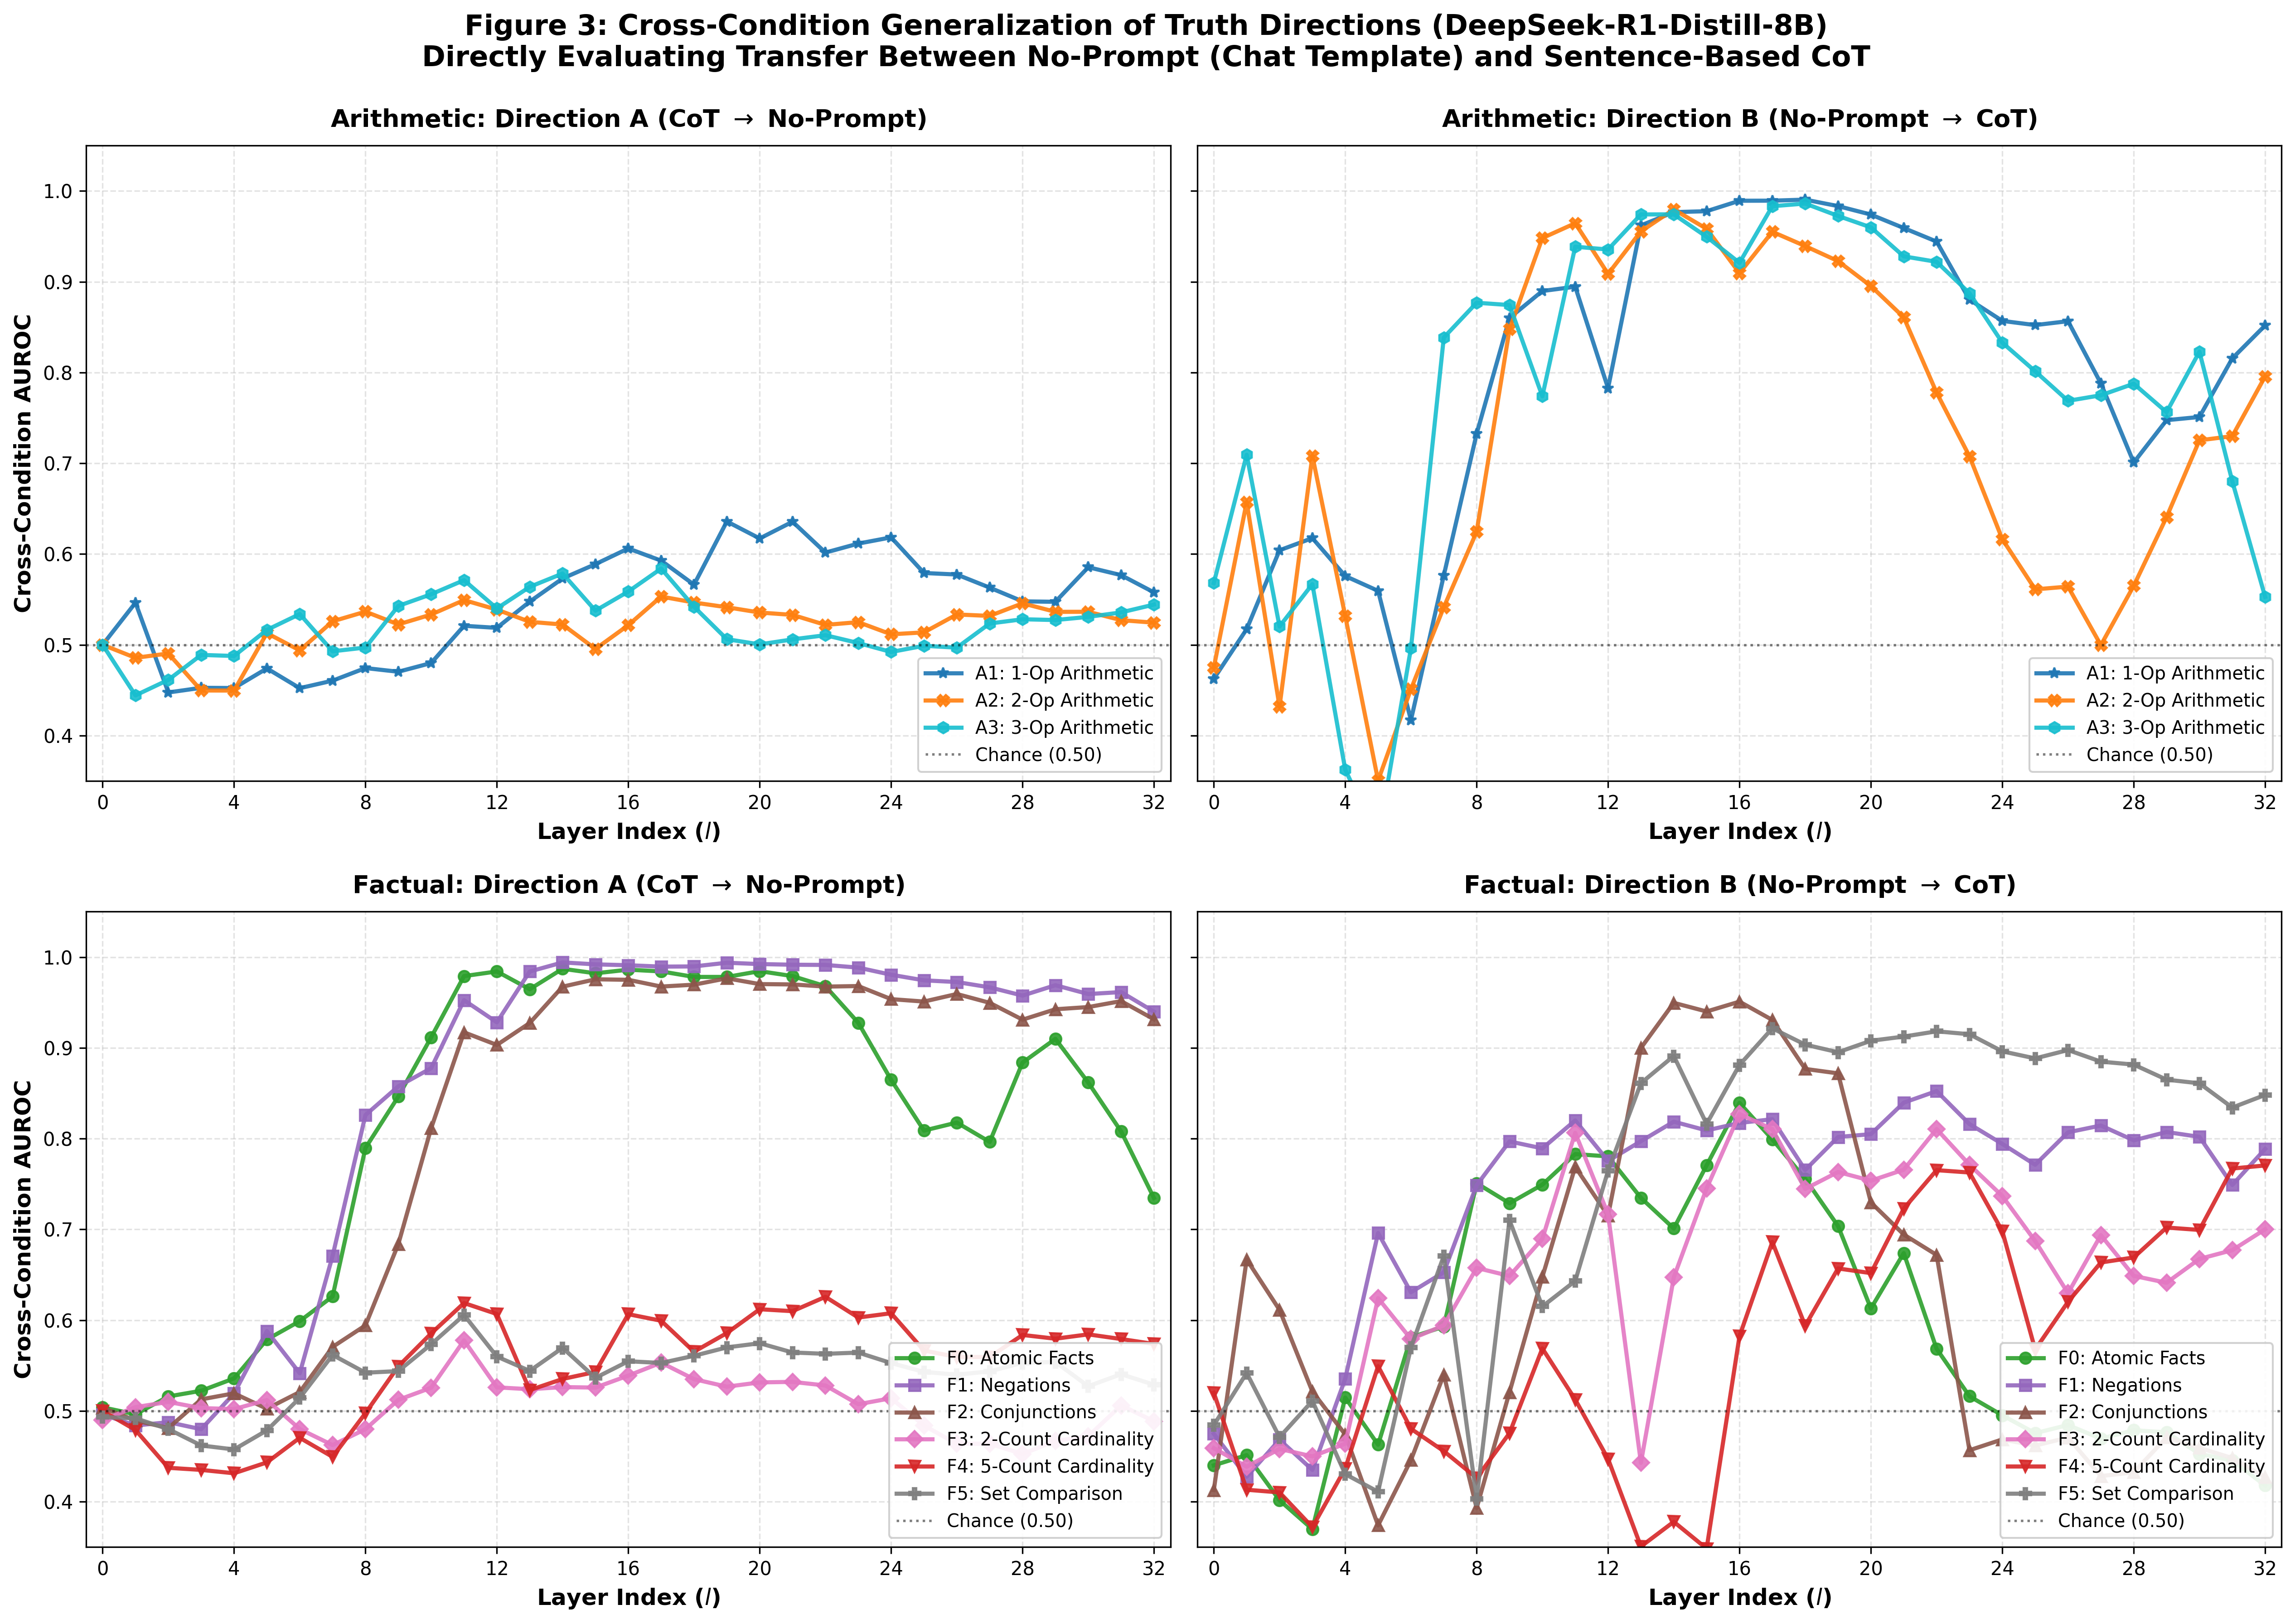

In [8]:
from IPython.display import Image, display

output_figures_dir = os.path.join(ROOT_DIR, 'experiments', 'figures', 'figure_3')
os.makedirs(output_figures_dir, exist_ok=True)

ARITH_TASKS = ['A1', 'A2', 'A3']
FACT_TASKS = ['F0', 'F1', 'F2', 'F3', 'F4', 'F5']

STYLE_MAP = {
    'A1': {'color': '#1f77b4', 'marker': '*', 'label': 'A1: 1-Op Arithmetic'},
    'A2': {'color': '#ff7f0e', 'marker': 'X', 'label': 'A2: 2-Op Arithmetic'},
    'A3': {'color': '#17becf', 'marker': 'h', 'label': 'A3: 3-Op Arithmetic'},
    'F0': {'color': '#2ca02c', 'marker': 'o', 'label': 'F0: Atomic Facts'},
    'F1': {'color': '#9467bd', 'marker': 's', 'label': 'F1: Negations'},
    'F2': {'color': '#8c564b', 'marker': '^', 'label': 'F2: Conjunctions'},
    'F3': {'color': '#e377c2', 'marker': 'D', 'label': 'F3: 2-Count Cardinality'},
    'F4': {'color': '#d62728', 'marker': 'v', 'label': 'F4: 5-Count Cardinality'},
    'F5': {'color': '#7f7f7f', 'marker': 'P', 'label': 'F5: Set Comparison'},
}

def load_cross_data(csv_path):
    df = pd.read_csv(csv_path)
    mask = (
        (df['model'] == 'deepseek-r1-distill-8b') &
        (df['train_task'] == df['test_task']) &
        (
            ((df['train_condition'] == 'sentence-based-CoT') & (df['test_condition'] == 'no-prompt-chat-template')) |
            ((df['train_condition'] == 'no-prompt-chat-template') & (df['test_condition'] == 'sentence-based-CoT'))
        )
    )
    cross_df = df[mask].copy()
    cross_df['layer'] = cross_df['layer'].astype(int)
    cross_df['auroc'] = cross_df['auroc'].astype(float)
    return cross_df

def plot_panel(ax, sub_df, tasks, title, show_ylabel=True):
    for task in tasks:
        cfg = STYLE_MAP[task]
        task_data = sub_df[sub_df['train_task'] == task].sort_values('layer')
        if len(task_data) > 0:
            ax.plot(
                task_data['layer'],
                task_data['auroc'],
                color=cfg['color'],
                marker=cfg['marker'],
                markersize=6,
                linewidth=2.2,
                alpha=0.9,
                label=cfg['label'],
            )
    ax.axhline(0.5, color='black', linestyle=':', alpha=0.5, linewidth=1.3, label='Chance (0.50)')
    ax.set_xlabel('Layer Index ($l$)', fontsize=12, fontweight='bold')
    if show_ylabel:
        ax.set_ylabel('Cross-Condition AUROC', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(0.35, 1.05)
    ax.set_xlim(-0.5, 32.5)
    ax.set_xticks(range(0, 33, 4))
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='lower right', fontsize=9.5, framealpha=0.9)

def save_fig(df, tr_cond, te_cond, tasks, title, filename):
    sub_df = df[(df['train_condition'] == tr_cond) & (df['test_condition'] == te_cond)]
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plot_panel(ax, sub_df, tasks, title, show_ylabel=True)
    plt.tight_layout()
    out_path = os.path.join(output_figures_dir, filename)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {filename}')

df_cross = load_cross_data(CSV_PATH)
print(f'Loaded {len(df_cross)} cross-condition rows from results_database.csv')

# 1. Arithmetic Tasks -- Direction A
save_fig(
    df_cross, 'sentence-based-CoT', 'no-prompt-chat-template', ARITH_TASKS,
    'Arithmetic Reasoning ($A_1-A_3$)\nDirection A: Train CoT $\\to$ Test No-Prompt',
    'figure_3_arithmetic_cot_to_noprompt.png'
)

# 2. Arithmetic Tasks -- Direction B
save_fig(
    df_cross, 'no-prompt-chat-template', 'sentence-based-CoT', ARITH_TASKS,
    'Arithmetic Reasoning ($A_1-A_3$)\nDirection B: Train No-Prompt $\\to$ Test CoT',
    'figure_3_arithmetic_noprompt_to_cot.png'
)

# 3. Factual Tasks -- Direction A
save_fig(
    df_cross, 'sentence-based-CoT', 'no-prompt-chat-template', FACT_TASKS,
    'Factual & Compositional Reasoning ($F_0-F_5$)\nDirection A: Train CoT $\\to$ Test No-Prompt',
    'figure_3_factual_cot_to_noprompt.png'
)

# 4. Factual Tasks -- Direction B
save_fig(
    df_cross, 'no-prompt-chat-template', 'sentence-based-CoT', FACT_TASKS,
    'Factual & Compositional Reasoning ($F_0-F_5$)\nDirection B: Train No-Prompt $\\to$ Test CoT',
    'figure_3_factual_noprompt_to_cot.png'
)

# 5. Comprehensive 2x2 Comparison Grid
fig, axes = plt.subplots(2, 2, figsize=(17, 12), sharey=True)
dir_a_df = df_cross[(df_cross['train_condition'] == 'sentence-based-CoT') & (df_cross['test_condition'] == 'no-prompt-chat-template')]
dir_b_df = df_cross[(df_cross['train_condition'] == 'no-prompt-chat-template') & (df_cross['test_condition'] == 'sentence-based-CoT')]

plot_panel(axes[0, 0], dir_a_df, ARITH_TASKS, 'Arithmetic: Direction A (CoT $\\to$ No-Prompt)', show_ylabel=True)
plot_panel(axes[0, 1], dir_b_df, ARITH_TASKS, 'Arithmetic: Direction B (No-Prompt $\\to$ CoT)', show_ylabel=False)
plot_panel(axes[1, 0], dir_a_df, FACT_TASKS, 'Factual: Direction A (CoT $\\to$ No-Prompt)', show_ylabel=True)
plot_panel(axes[1, 1], dir_b_df, FACT_TASKS, 'Factual: Direction B (No-Prompt $\\to$ CoT)', show_ylabel=False)

plt.suptitle(
    'Figure 3: Cross-Condition Generalization of Truth Directions (DeepSeek-R1-Distill-8B)\n'
    'Directly Evaluating Transfer Between No-Prompt (Chat Template) and Sentence-Based CoT',
    fontsize=15,
    fontweight='bold',
    y=0.995,
)
plt.tight_layout()
comp_path = os.path.join(output_figures_dir, 'figure_3_cross_condition_comprehensive.png')
plt.savefig(comp_path, dpi=300, bbox_inches='tight')
plt.close()
print(f'Saved: figure_3_cross_condition_comprehensive.png')

if os.path.exists(comp_path):
    display(Image(filename=comp_path))


EXPORT_CSV_START
train_task,test_task,train_condition,test_condition,layer,model,auroc
A1,A1,sentence-based-CoT,no-prompt-chat-template,0,deepseek-r1-distill-8b,0.5
A1,A1,no-prompt-chat-template,sentence-based-CoT,0,deepseek-r1-distill-8b,0.4625850340136054
A1,A1,sentence-based-CoT,no-prompt-chat-template,1,deepseek-r1-distill-8b,0.5463555555555555
A1,A1,no-prompt-chat-template,sentence-based-CoT,1,deepseek-r1-distill-8b,0.517233560090703
A1,A1,sentence-based-CoT,no-prompt-chat-template,2,deepseek-r1-distill-8b,0.4474666666666666
A1,A1,no-prompt-chat-template,sentence-based-CoT,2,deepseek-r1-distill-8b,0.6041269841269841
A1,A1,sentence-based-CoT,no-prompt-chat-template,3,deepseek-r1-distill-8b,0.4526222222222222
A1,A1,no-prompt-chat-template,sentence-based-CoT,3,deepseek-r1-distill-8b,0.6175510204081633
A1,A1,sentence-based-CoT,no-prompt-chat-template,4,deepseek-r1-distill-8b,0.4523555555555555
A1,A1,no-prompt-chat-template,sentence-based-CoT,4,deepseek-r1-distill-8b,0.5757369614512472

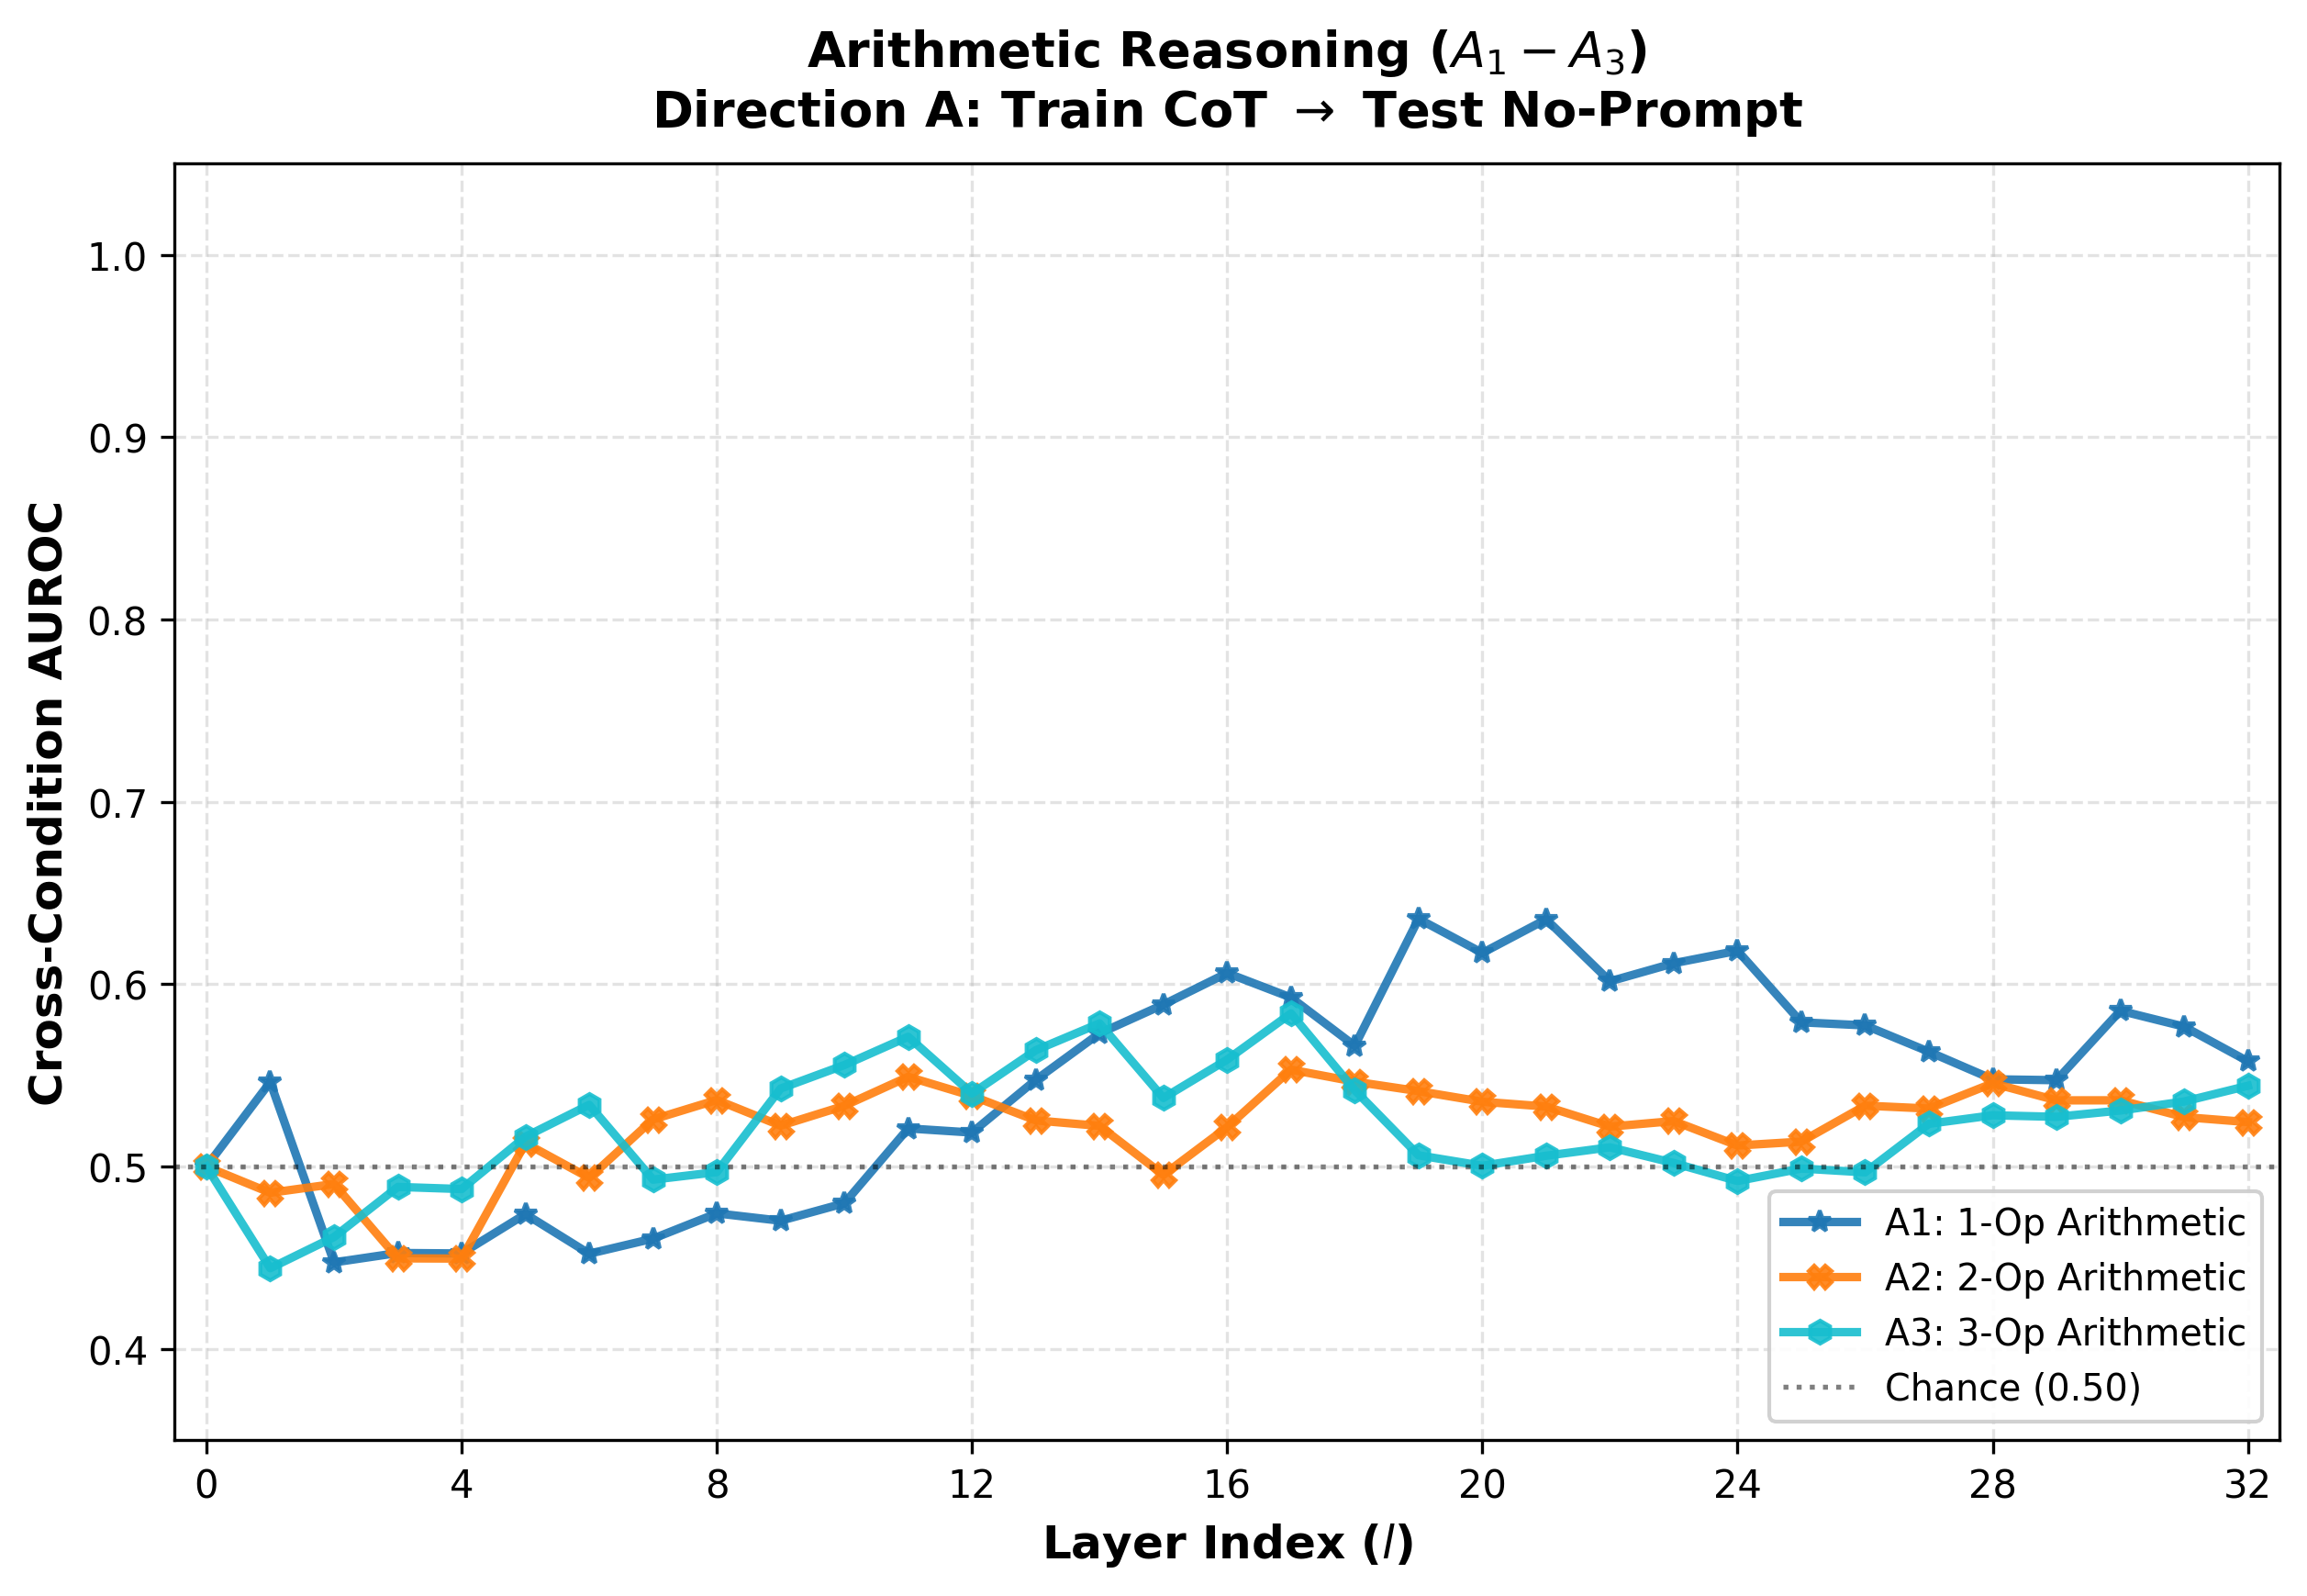

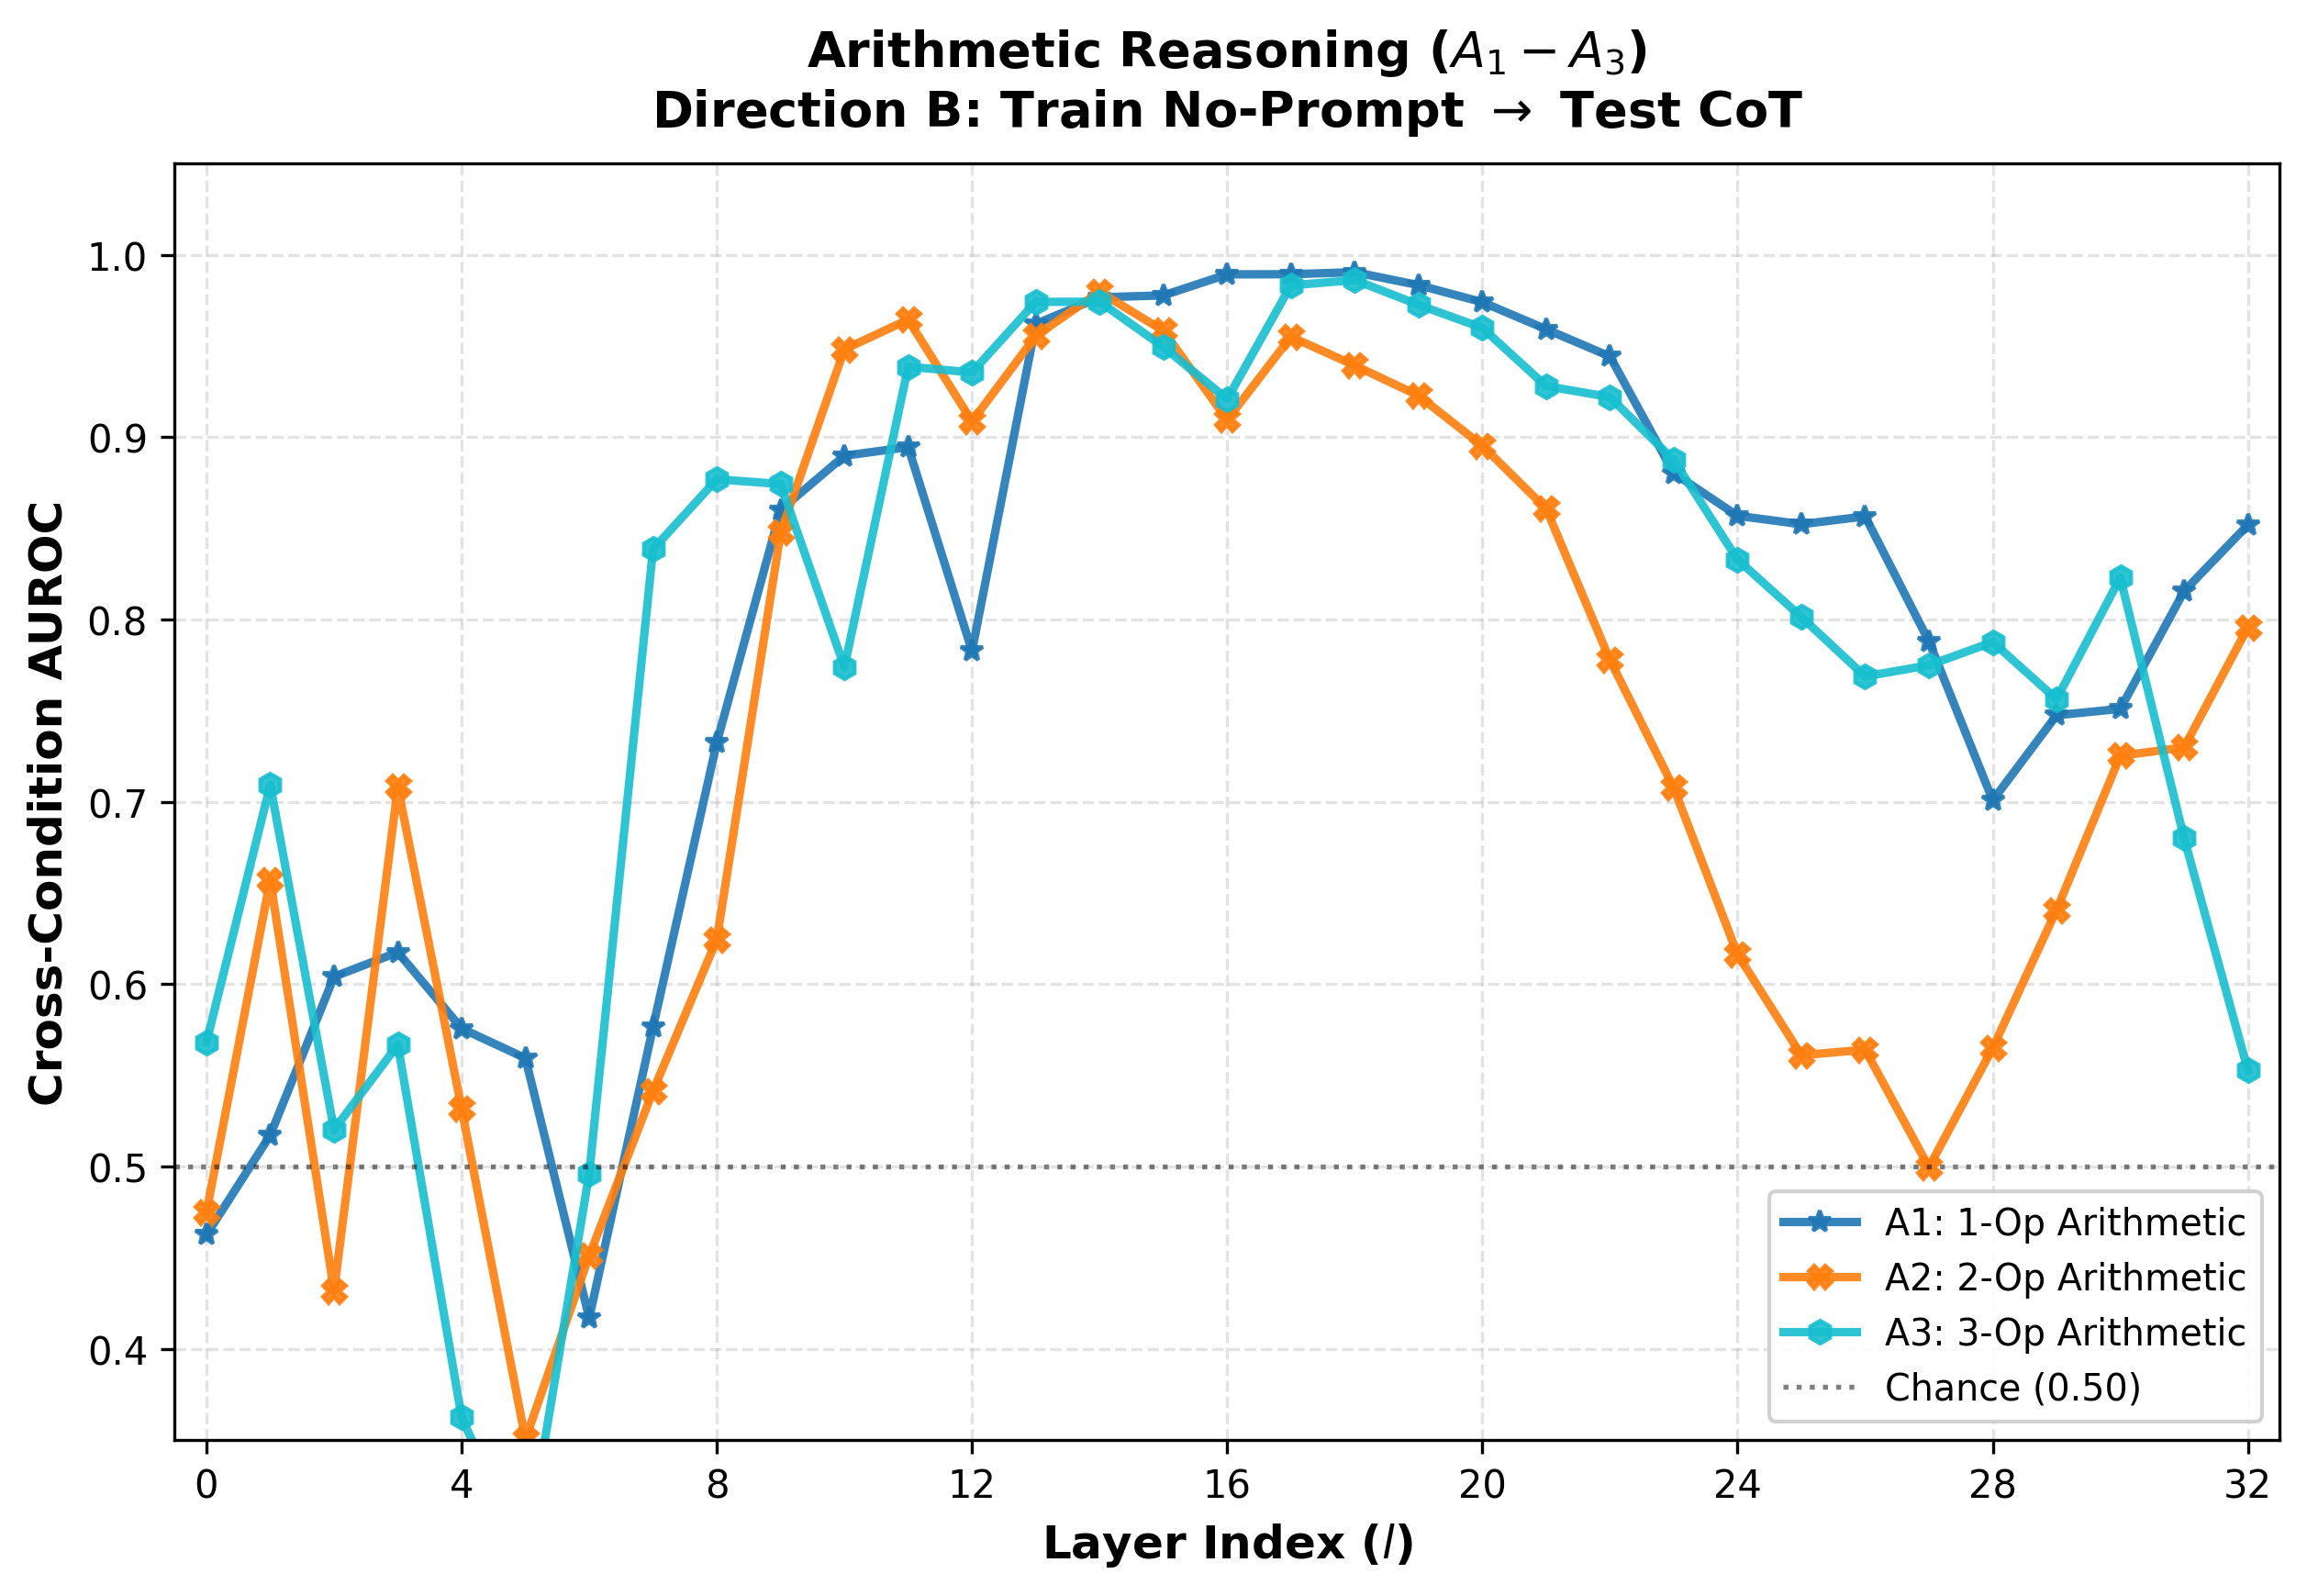

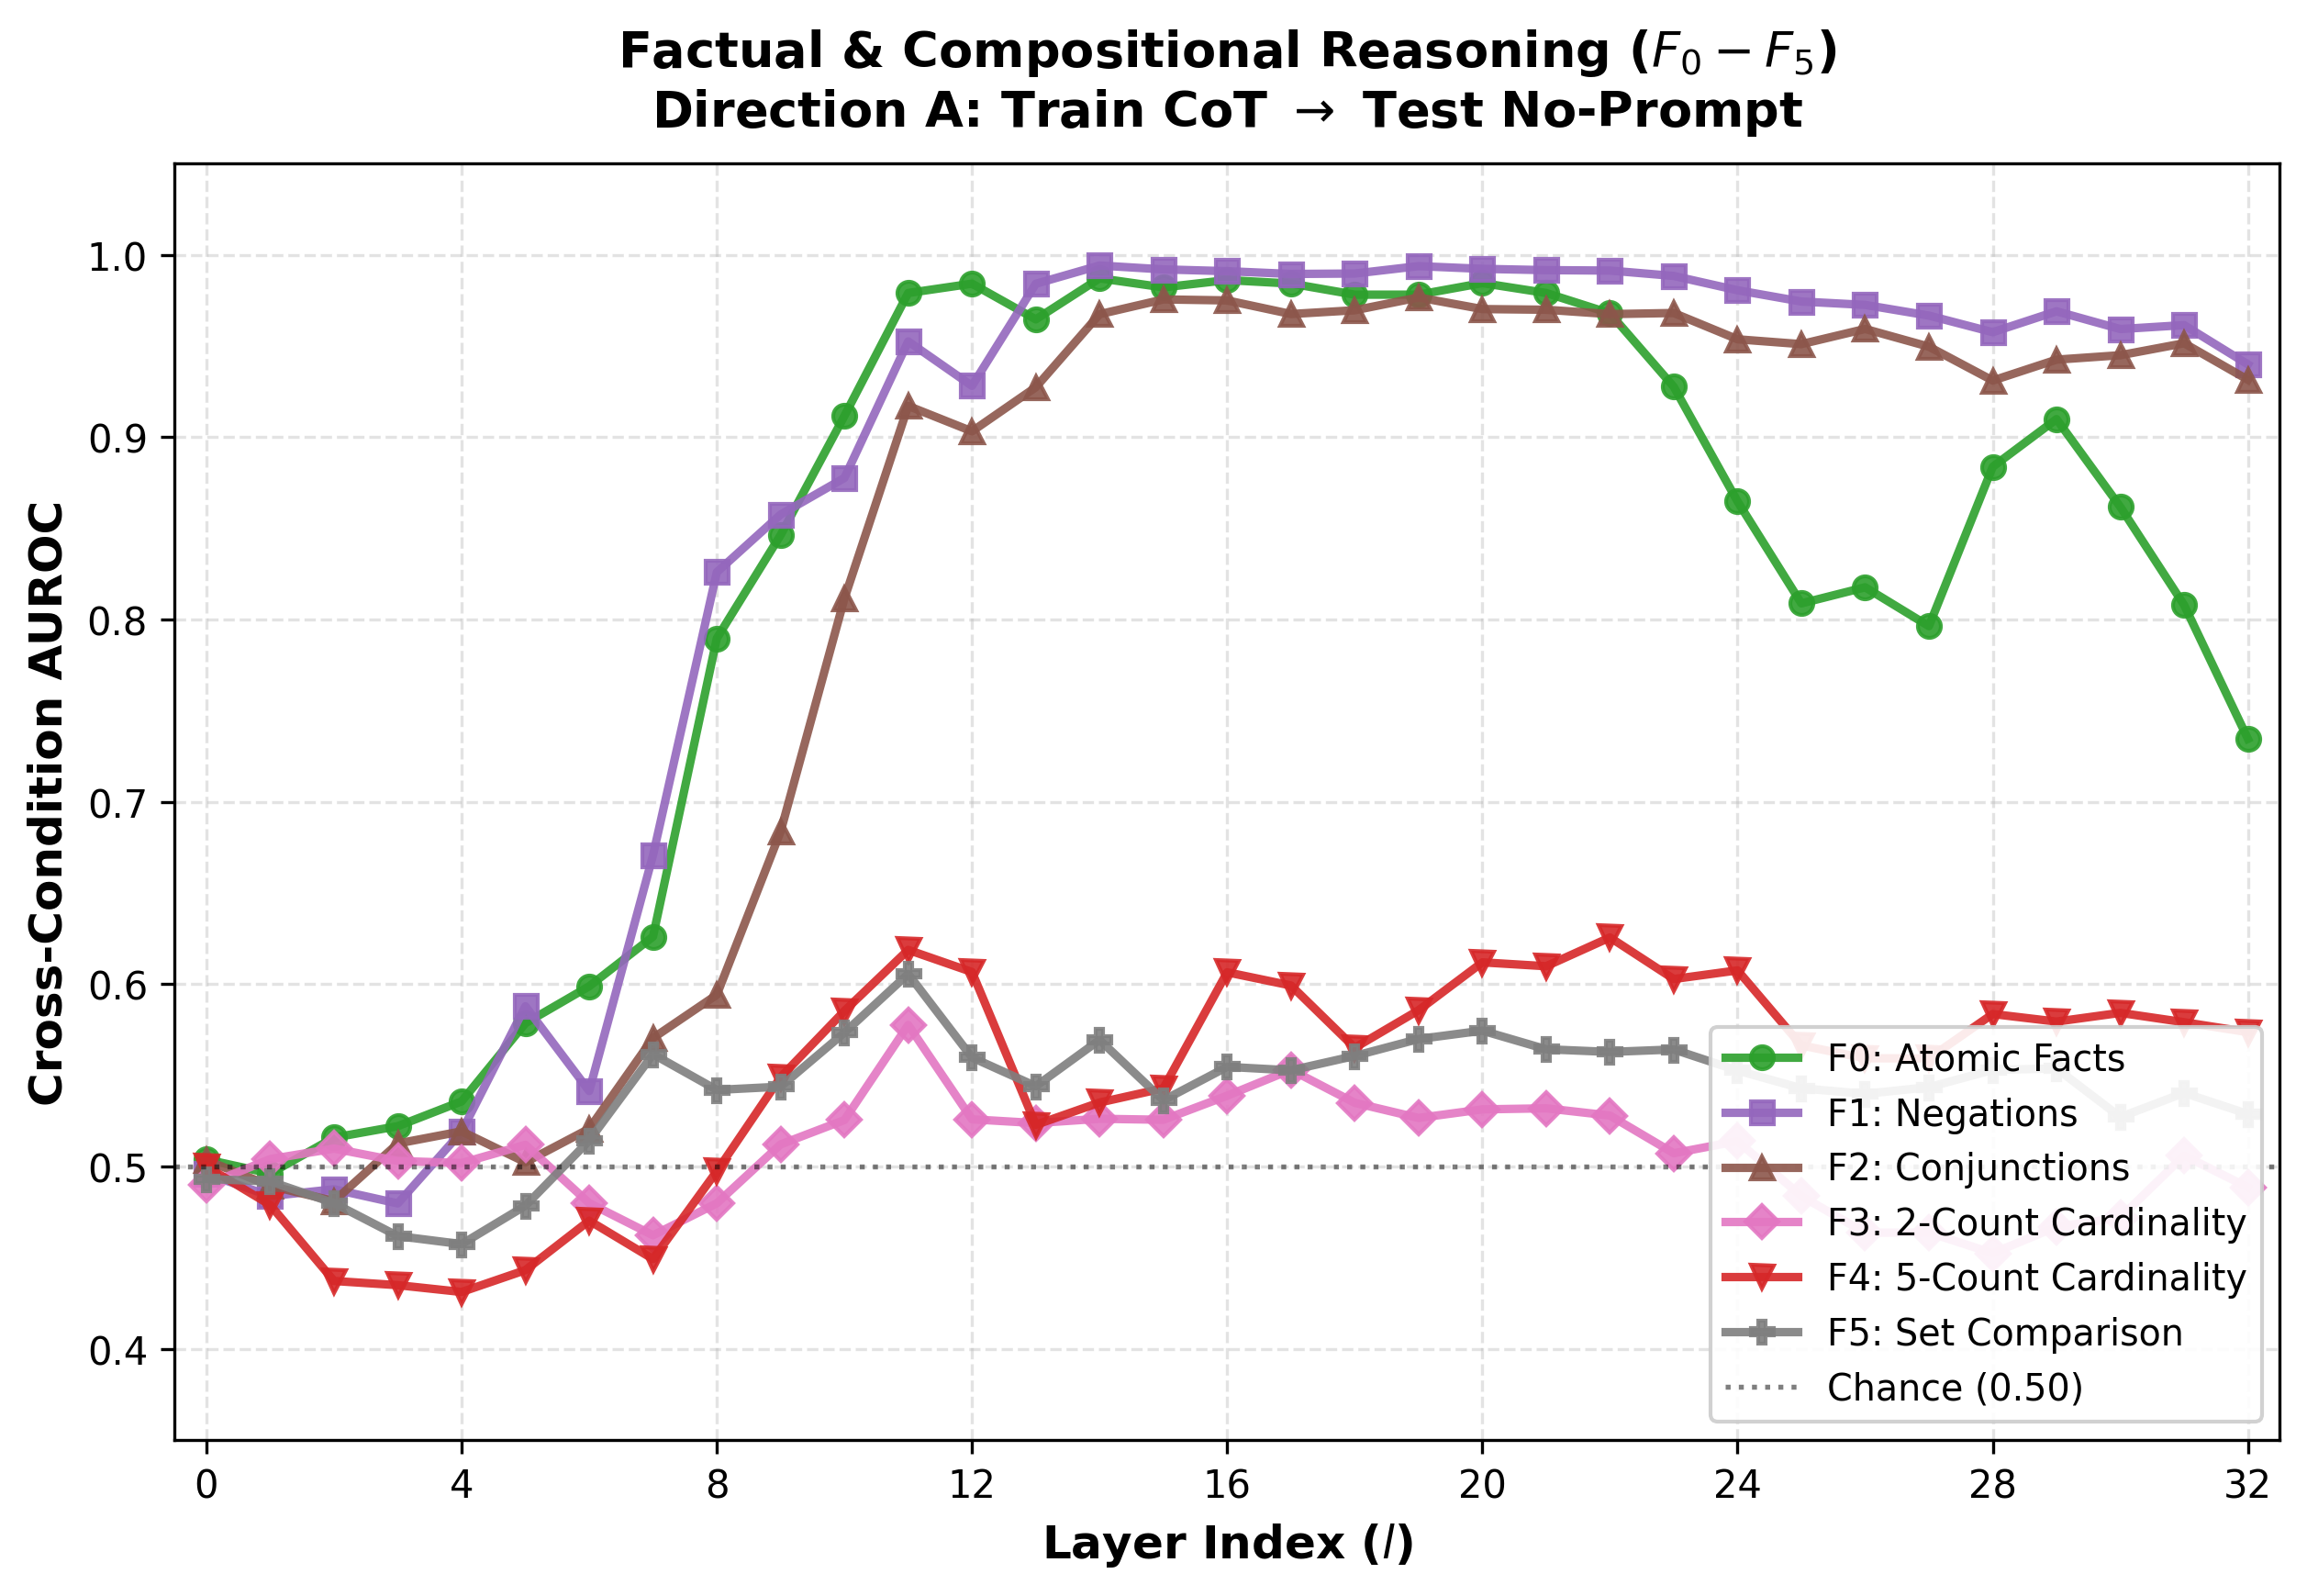

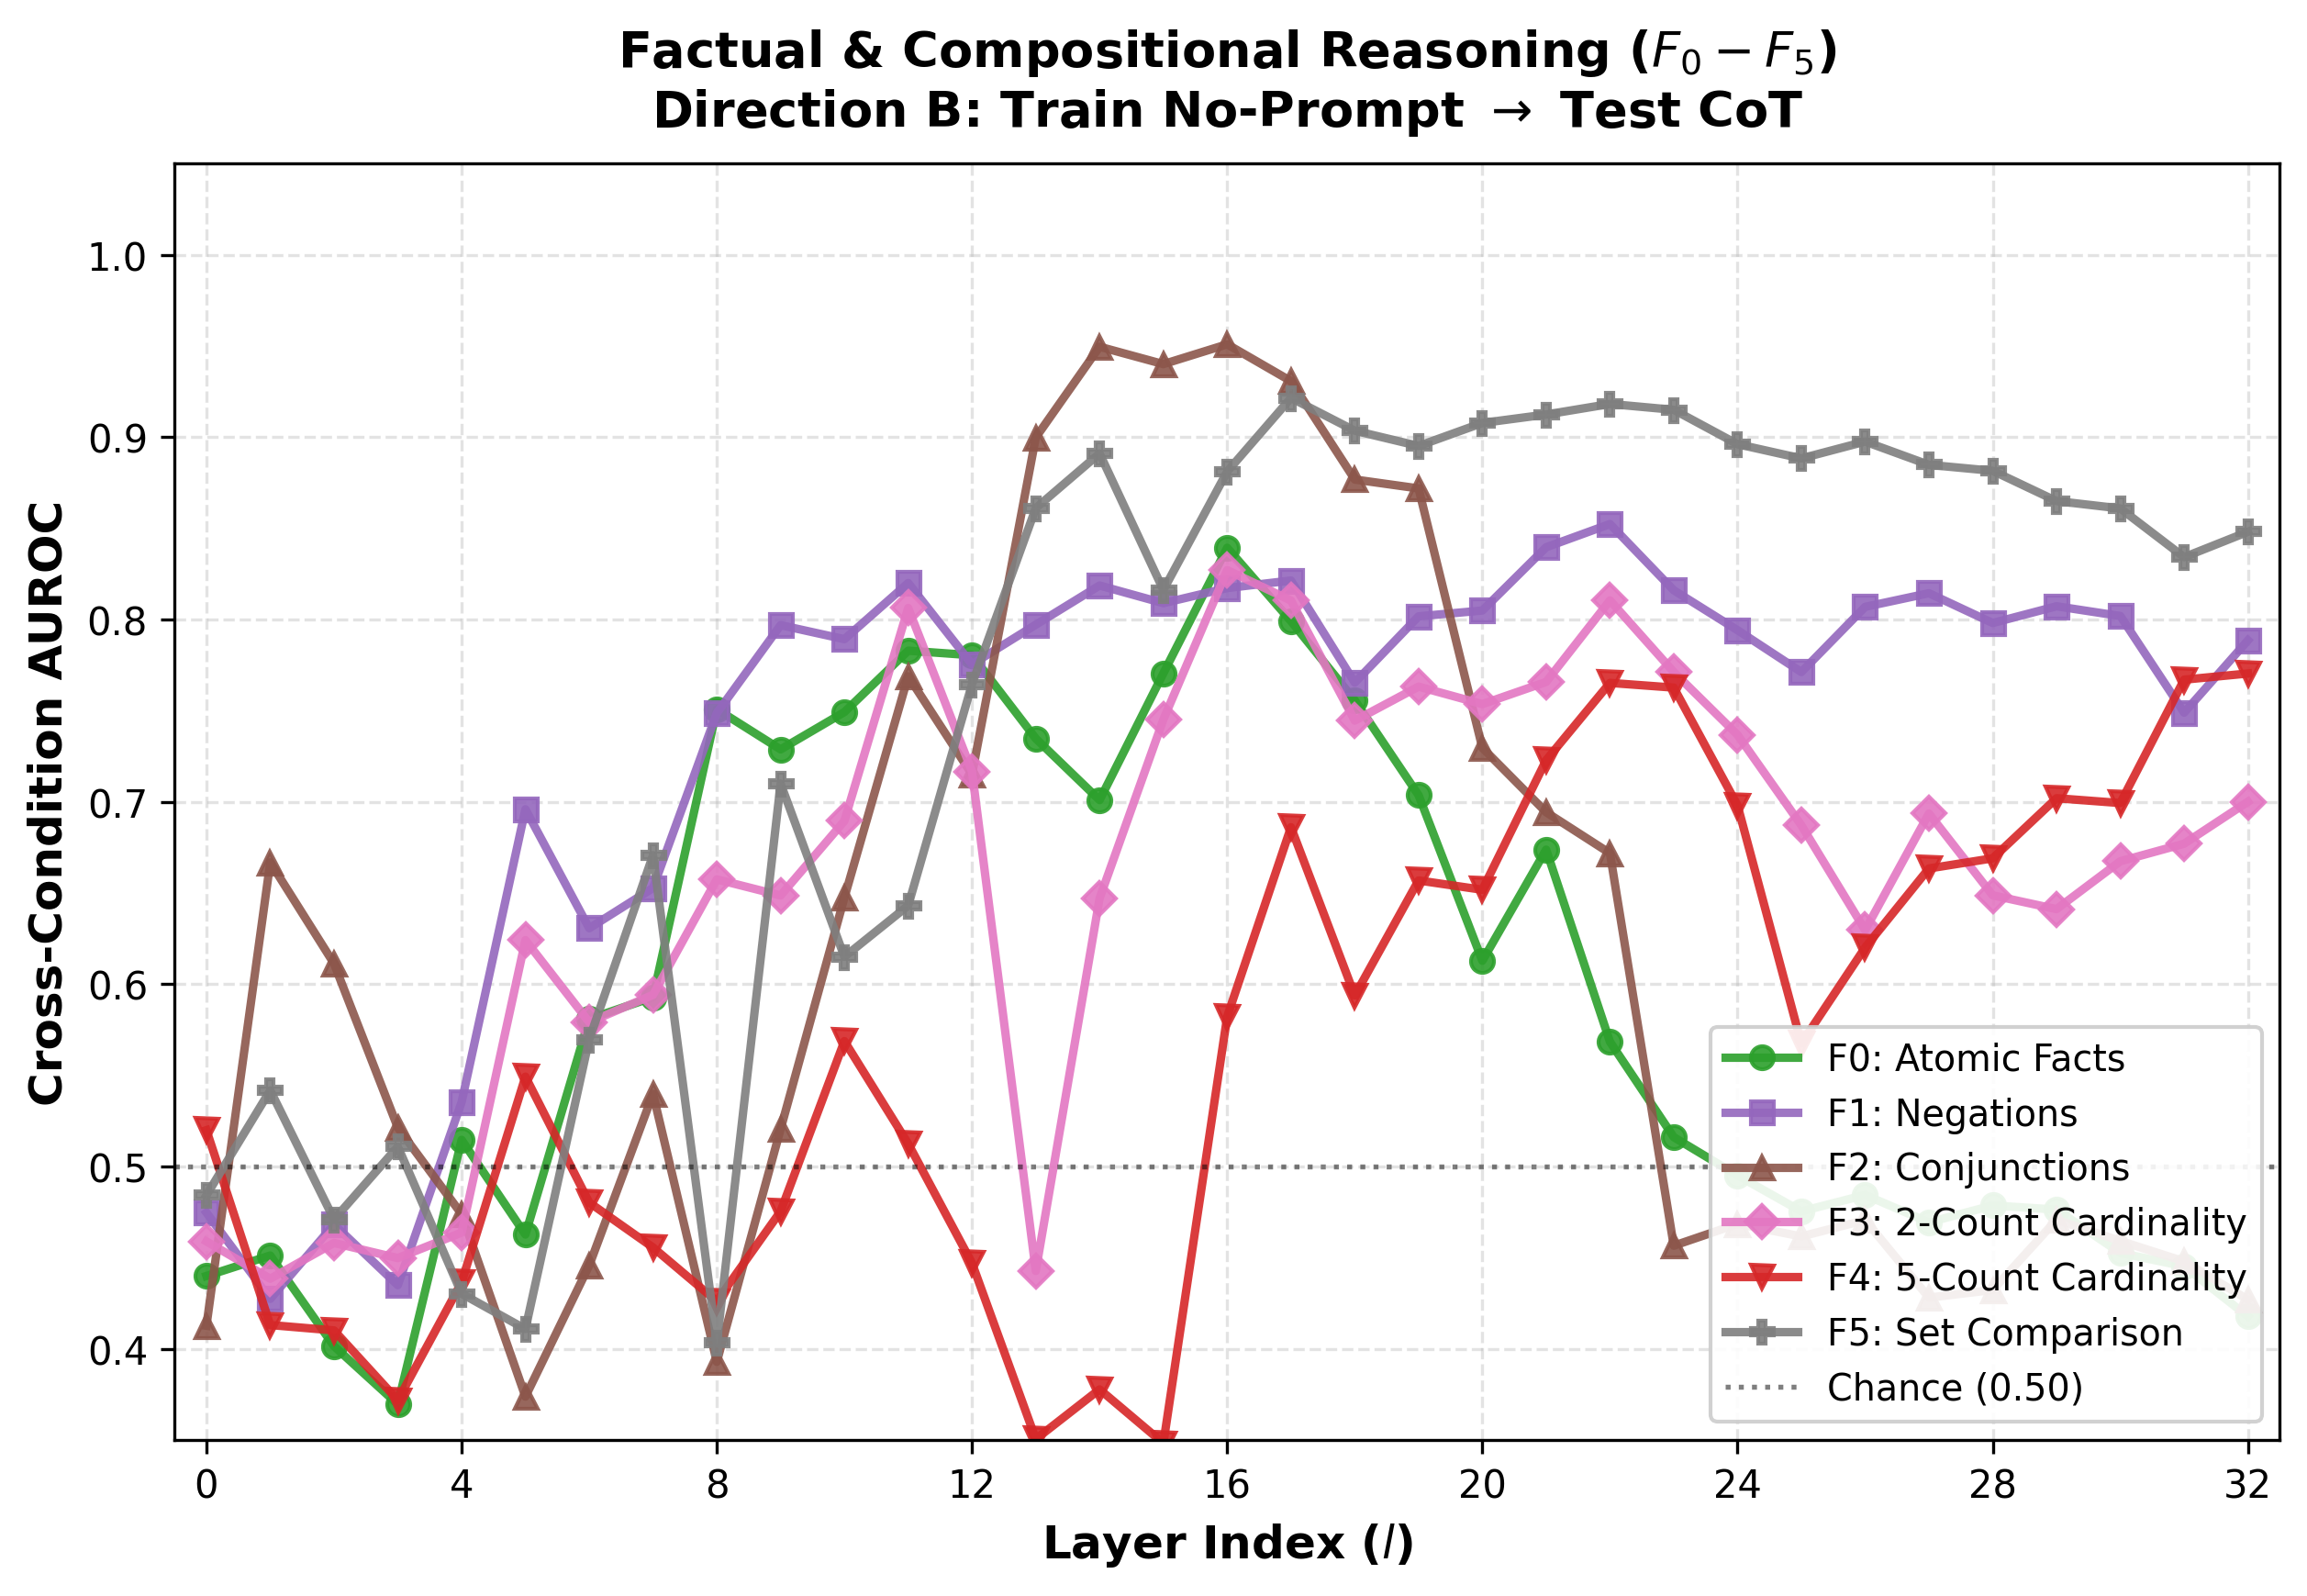

In [9]:
# Cell 8: Sync CSV rows and figures to local repository
df_db = pd.read_csv(CSV_PATH)
cross_df = df_db[
    (df_db['model'] == 'deepseek-r1-distill-8b') &
    (df_db['train_task'] == df_db['test_task']) &
    (
        ((df_db['train_condition'] == 'sentence-based-CoT') & (df_db['test_condition'] == 'no-prompt-chat-template')) |
        ((df_db['train_condition'] == 'no-prompt-chat-template') & (df_db['test_condition'] == 'sentence-based-CoT'))
    )
]
print('EXPORT_CSV_START')
print(cross_df.to_csv(index=False))
print('EXPORT_CSV_END')

for fname in [
    'figure_3_arithmetic_cot_to_noprompt.png',
    'figure_3_arithmetic_noprompt_to_cot.png',
    'figure_3_factual_cot_to_noprompt.png',
    'figure_3_factual_noprompt_to_cot.png'
]:
    fpath = os.path.join(output_figures_dir, fname)
    if os.path.exists(fpath):
        display(Image(filename=fpath))
